In [3]:
from scipy import stats
import numpy as np
import pandas as pd
import yfinance as yf 

spy = yf.download("SPY", start="2020-01-01", end="2026-01-01") 
spy.columns = spy.columns.get_level_values(0)
spy["Daily Return"] = spy["Close"].pct_change().dropna()
returns = spy["Daily Return"].dropna()

[*********************100%***********************]  1 of 1 completed


In [4]:
print(f"Mean = {returns.mean():.3f}")
print(f"Standard Devation = {returns.std():.3f}")

#skewness = are big values more skewed towards the top or bottom of the dataset? 
#in this case, it is asking whether big changes in daily returns are more likely to be positive or negative
print(f"Skewness = {stats.skew(returns):.3f}") 

#kurtosis = measures tail fatness — are there more extreme movements?
#high kurtosis means there is more extreme movement than would be expected by typical std model 
print(f"Kurtosis = {stats.kurtosis(returns):.3f}")

Mean = 0.001
Standard Devation = 0.013
Skewness = -0.264
Kurtosis = 12.999


In [34]:
#p-value test for normal distribution 
ticker = yf.download(input("Enter ticker: "), start="2020-01-01", end="2026-06-01")
ticker.columns = ticker.columns.get_level_values(0) 
ticker["Daily Return"] = ticker["Close"].pct_change().dropna()
returns = ticker["Daily Return"].dropna()
stat, p_value = stats.normaltest(returns)
print(f"Test Statistic = {stat:.2f}")
print(f"P-value = {p_value:.4f}")
if p_value < 0.05:
    print("Returns are not normally distributed") #there is a significant diff between the stock's returns and normal distribution
    #alpha generation is driven by real factors, not random chance 
else:
    print("Returns are normally distributed") 

Enter ticker:  qqq


[*********************100%***********************]  1 of 1 completed

Test Statistic = 240.69
P-value = 0.0000
Returns are not normally distributed


In [7]:
#t-test for comparing stock distributions
ticker1 = yf.download(input("Ticker 1: "), start="2020-01-01", end="2026-06-01")
ticker1.columns = ticker1.columns.get_level_values(0)
ticker2 = yf.download(input("Ticker 2: "), start="2020-01-01", end="2026-06-01")
ticker2.columns = ticker2.columns.get_level_values(0)

ticker1_returns = ticker1["Close"].pct_change().dropna()
ticker2_returns = ticker2["Close"].pct_change().dropna()

t_stat, p_value = stats.ttest_ind(ticker1_returns, ticker2_returns)
print(f"T-stat = {t_stat:.4f}")
print(f"P-value = {p_value:.4f}")

if p_value < 0.05:
    print("The returns are statistically different") #difference in returns is not due to random chance 
else:
    print("No statistically significant difference between returns")

Ticker 1:  NVDA


[*********************100%***********************]  1 of 1 completed


Ticker 2:  MO


[*********************100%***********************]  1 of 1 completed

T-stat = 2.3471
P-value = 0.0190
The returns are statistically different


In [31]:
#ols regression choose two stocks 
import statsmodels.api as sm

stock1 = input("Ticker 1: ")
stock2 = input("Ticker 2: ")

ticker3 = yf.download(stock1, start="2020-01-01", end="2026-06-01")
ticker3.columns = ticker3.columns.get_level_values(0)
ticker4 = yf.download(stock2, start="2020-01-01", end="2026-06-01")
ticker4.columns = ticker3.columns.get_level_values(0)

ticker3_returns = ticker3["Close"].pct_change().dropna()
ticker4_returns = ticker4["Close"].pct_change().dropna()

#align
ticker3_returns, ticker4_returns = ticker3_returns.align(ticker4_returns, join="inner") 

#run ols
X = sm.add_constant(ticker3_returns)
model = sm.OLS(ticker4_returns, X).fit()
print(model.summary())

print(f"\nR-squared = {model.rsquared:.4f}")

alpha = model.params["const"]
beta = model.params["Close"]

print(f"Alpha: {alpha:.6f}")
print(f"Beta: {beta:.4f}")
print(f"P-values:\n{model.pvalues}") 
print(f"Confidence interval:\n{model.conf_int()}")

Ticker 1:  AAPL
Ticker 2:  AMZN


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

                            OLS Regression Results                            
Dep. Variable:                  Close   R-squared:                       0.330
Model:                            OLS   Adj. R-squared:                  0.330
Method:                 Least Squares   F-statistic:                     792.2
Date:                Sat, 06 Jun 2026   Prob (F-statistic):          4.94e-142
Time:                        12:22:30   Log-Likelihood:                 4160.6
No. Observations:                1609   AIC:                            -8317.
Df Residuals:                    1607   BIC:                            -8306.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.000      0.404      0.6

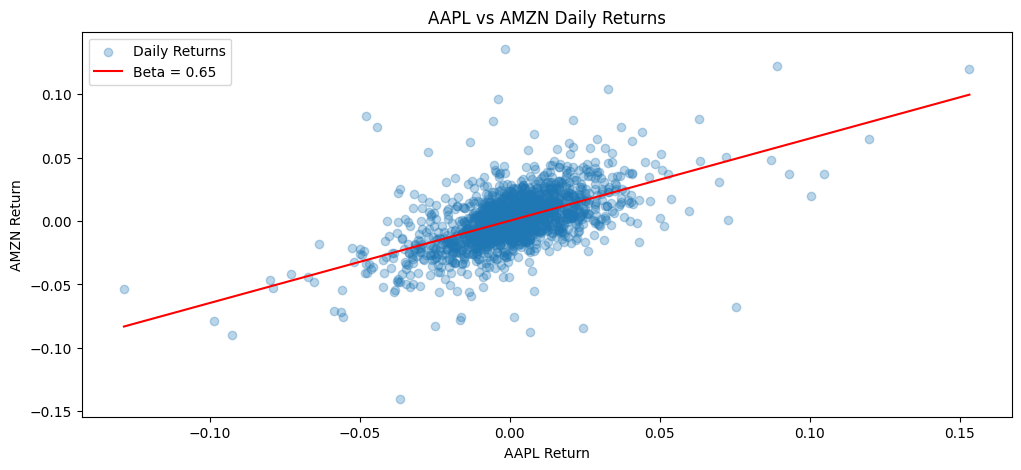

In [33]:
#plot daily returns and beta 
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.scatter(ticker3_returns, ticker4_returns, alpha=0.3, label="Daily Returns")

x_line = np.linspace(ticker3_returns.min(), ticker3_returns.max(), 100) 
y_line = alpha + beta * x_line
plt.plot(x_line, y_line, color="red", label=f"Beta = {beta:.2f}")

plt.title(f"{stock1} vs {stock2} Daily Returns")
plt.xlabel(f"{stock1} Return")
plt.ylabel(f"{stock2} Return")
plt.legend()
plt.show()

In [41]:
#ols regression plot one stock against the market 
stock = input("Stock: ")

stock_data = yf.download(stock, start="2020-01-01", end="2026-06-01")
stock_data.columns = stock_data.columns.get_level_values(0)

stock_returns = stock_data["Close"].pct_change().dropna()

#align
returns, stock_returns = returns.align(stock_returns, join="inner") 

#run ols
X = sm.add_constant(returns)
model = sm.OLS(stock_returns, X).fit()
print(model.summary())

print(f"\nR-squared = {model.rsquared:.4f}")

alpha = model.params["const"]
beta = model.params["Daily Return"]

print(f"Alpha: {alpha:.6f}")
print(f"Beta: {beta:.4f}")
print(f"P-values:\n{model.pvalues}") 
print(f"Confidence interval:\n{model.conf_int()}")

Stock:  SPOT


[*********************100%***********************]  1 of 1 completed

                            OLS Regression Results                            
Dep. Variable:                  Close   R-squared:                       0.273
Model:                            OLS   Adj. R-squared:                  0.273
Method:                 Least Squares   F-statistic:                     604.1
Date:                Sat, 06 Jun 2026   Prob (F-statistic):          1.66e-113
Time:                        12:42:56   Log-Likelihood:                 3556.6
No. Observations:                1609   AIC:                            -7109.
Df Residuals:                    1607   BIC:                            -7098.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0003      0.001      0.422   

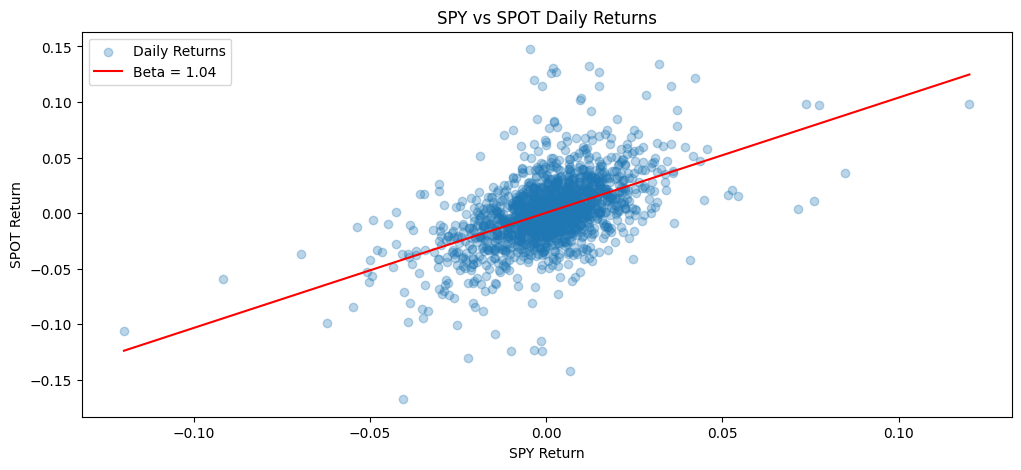

In [42]:
#plot
plt.figure(figsize=(12,5))
plt.scatter(returns, stock_returns, alpha=0.3, label="Daily Returns")

x_line = np.linspace(returns.min(), returns.max(), 100) 
y_line = alpha + beta * x_line
plt.plot(x_line, y_line, color="red", label=f"Beta = {beta:.2f}")

plt.title(f"SPY vs {stock} Daily Returns")
plt.xlabel(f"SPY Return")
plt.ylabel(f"{stock} Return")
plt.legend()
plt.show()